# 📊 Data Science Internship — Project 1

## E-Commerce Data Analysis

**Internship Organization: DecodeLabs**

### Project Overview

This project is completed as part of my **Data Science Internship at DecodeLabs**.

The project focuses on analyzing an e-commerce orders dataset using Python and Pandas. A structured data science workflow is followed, including data inspection, cleaning, validation, exploratory data analysis, and data visualization.

The primary objective is to transform raw e-commerce data into meaningful insights while maintaining data quality and carefully interpreting the results.

## Project Objectives

* Understand the structure and characteristics of the provided dataset
* Perform data inspection and preprocessing
* Identify and handle missing values
* Check for duplicate records
* Detect and evaluate potential outliers
* Validate numerical, categorical, and date-related data
* Verify the consistency of order price calculations
* Analyze products, customers, payment methods, order statuses, coupons, and referral sources
* Examine monthly order-value trends
* Create meaningful visualizations using Matplotlib
* Summarize and interpret the key findings from the analysis

## Tools & Technologies

* Python
* Pandas
* Matplotlib
* Jupyter Notebook
* Microsoft Excel
* GitHub


In [368]:
import pandas as pd

df = pd.read_excel("Dataset_for_Data_Analytics.xlsx")

print(df.head())

     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREESHIP  

In [369]:
%pip install pandas openpyxl

Note: you may need to restart the kernel to use updated packages.


In [370]:
import pandas as pd

df = pd.read_excel("Dataset_for_Data_Analytics.xlsx")

print(df.head())

     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREESHIP  

In [371]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (1200, 14)

Column Names:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  

## 🧹 Data Cleaning & Validation

The dataset was systematically checked and cleaned to ensure data quality and reliability.

### Cleaning & Validation Steps

* Checked for missing values and handled missing coupon codes by labeling them as **"No Coupon"**
* Checked for duplicate records
* Validated categorical values such as Product, Payment Method, Order Status, Referral Source, and Coupon Code
* Checked numerical columns for invalid values and potential outliers
* Investigated potential outliers in order-value data and retained valid observations
* Verified that `TotalPrice` is consistent with `Quantity × UnitPrice`
* Validated date values and confirmed that there are no missing or future dates

After cleaning and validation, the dataset contains **1,200 records with no remaining missing values or duplicate rows**.


In [372]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


In [373]:
print("Coupon Code Values:")
print(df["CouponCode"].value_counts(dropna=False))

Coupon Code Values:
CouponCode
FREESHIP    313
NaN         309
WINTER15    292
SAVE10      286
Name: count, dtype: int64


In [374]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [375]:
print(df[["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]].describe())

          Quantity    UnitPrice  ItemsInCart   TotalPrice
count  1200.000000  1200.000000  1200.000000  1200.000000
mean      2.945833   356.412750     5.485000  1053.968300
std       1.407557   197.177146     2.281983   819.856558
min       1.000000    11.390000     1.000000    11.390000
25%       2.000000   186.062500     4.000000   410.520000
50%       3.000000   364.210000     5.000000   823.615000
75%       4.000000   521.570000     7.000000  1578.475000
max       5.000000   699.930000    10.000000  3456.400000


In [376]:
df["CalculatedTotal"] = df["Quantity"] * df["UnitPrice"]

print("Rows where TotalPrice does not match:")
print((df["TotalPrice"] != df["CalculatedTotal"]).sum())

Rows where TotalPrice does not match:
107


In [377]:
df["PriceDifference"] = df["TotalPrice"] - df["CalculatedTotal"]

print(df.loc[df["PriceDifference"] != 0,
             ["Quantity", "UnitPrice", "TotalPrice", "CalculatedTotal", "PriceDifference"]].head(20))

     Quantity  UnitPrice  TotalPrice  CalculatedTotal  PriceDifference
2           5     550.68     2753.40          2753.40     4.547474e-13
10          5     625.97     3129.85          3129.85    -4.547474e-13
11          3      49.14      147.42           147.42    -2.842171e-14
32          5     536.72     2683.60          2683.60    -4.547474e-13
41          3     611.45     1834.35          1834.35    -2.273737e-13
43          3     499.21     1497.63          1497.63     2.273737e-13
55          3     344.40     1033.20          1033.20     2.273737e-13
56          3     479.21     1437.63          1437.63     2.273737e-13
64          3     130.61      391.83           391.83    -5.684342e-14
69          3     478.65     1435.95          1435.95     2.273737e-13
80          3     589.56     1768.68          1768.68     2.273737e-13
85          3     146.73      440.19           440.19    -5.684342e-14
86          5     643.03     3215.15          3215.15     4.547474e-13
109   

In [378]:
df["PriceDifference"] = (
    df["TotalPrice"] - df["CalculatedTotal"]
).abs()

print("Actual differences greater than 0.01:",
      (df["PriceDifference"] > 0.01).sum())

Actual differences greater than 0.01: 0


In [379]:
print("Products:")
print(df["Product"].value_counts())

print("\nPayment Methods:")
print(df["PaymentMethod"].value_counts())

print("\nOrder Status:")
print(df["OrderStatus"].value_counts())

Products:
Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

Payment Methods:
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

Order Status:
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


In [380]:
print("Date Range:")
print("Start:", df["Date"].min())
print("End:", df["Date"].max())

print("\nOrders by Year:")
print(df["Date"].dt.year.value_counts().sort_index())

Date Range:
Start: 2023-01-01 00:00:00
End: 2025-06-30 00:00:00

Orders by Year:
Date
2023    510
2024    459
2025    231
Name: count, dtype: int64


In [381]:
Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 410.52
Q3: 1578.475
IQR: 1167.955
Lower Bound: -1341.4125
Upper Bound: 3330.4075


In [382]:
outliers = df[
    (df["TotalPrice"] < lower_bound) |
    (df["TotalPrice"] > upper_bound)
]

print("Number of potential outliers:", len(outliers))

Number of potential outliers: 8


In [383]:
print(outliers[["OrderID", "Product", "Quantity", "UnitPrice", "TotalPrice"]])

        OrderID  Product  Quantity  UnitPrice  TotalPrice
107   ORD200107  Printer         5     670.75     3353.75
326   ORD200326   Laptop         5     670.48     3352.40
328   ORD200328   Tablet         5     674.04     3370.20
469   ORD200469    Chair         5     676.98     3384.90
632   ORD200632   Laptop         5     678.16     3390.80
789   ORD200789   Tablet         5     691.28     3456.40
1065  ORD201065  Printer         5     666.80     3334.00
1122  ORD201122  Monitor         5     678.19     3390.95


In [384]:
Q1_price = df["UnitPrice"].quantile(0.25)
Q3_price = df["UnitPrice"].quantile(0.75)

IQR_price = Q3_price - Q1_price

lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price

print("Q1:", Q1_price)
print("Q3:", Q3_price)
print("IQR:", IQR_price)
print("Lower Bound:", lower_price)
print("Upper Bound:", upper_price)

Q1: 186.0625
Q3: 521.5699999999999
IQR: 335.50749999999994
Lower Bound: -317.1987499999999
Upper Bound: 1024.8312499999997


In [385]:
price_outliers = df[
    (df["UnitPrice"] < lower_price) |
    (df["UnitPrice"] > upper_price)
]

print("Number of UnitPrice outliers:", len(price_outliers))

Number of UnitPrice outliers: 0


In [386]:
Q1_quantity = df["Quantity"].quantile(0.25)
Q3_quantity = df["Quantity"].quantile(0.75)

IQR_quantity = Q3_quantity - Q1_quantity

lower_quantity = Q1_quantity - 1.5 * IQR_quantity
upper_quantity = Q3_quantity + 1.5 * IQR_quantity

print("Q1:", Q1_quantity)
print("Q3:", Q3_quantity)
print("IQR:", IQR_quantity)
print("Lower Bound:", lower_quantity)
print("Upper Bound:", upper_quantity)

Q1: 2.0
Q3: 4.0
IQR: 2.0
Lower Bound: -1.0
Upper Bound: 7.0


In [387]:
quantity_outliers = df[
    (df["Quantity"] < lower_quantity) |
    (df["Quantity"] > upper_quantity)
]

print("Number of Quantity outliers:", len(quantity_outliers))

Number of Quantity outliers: 0


In [388]:
Q1_cart = df["ItemsInCart"].quantile(0.25)
Q3_cart = df["ItemsInCart"].quantile(0.75)

IQR_cart = Q3_cart - Q1_cart

lower_cart = Q1_cart - 1.5 * IQR_cart
upper_cart = Q3_cart + 1.5 * IQR_cart

print("Q1:", Q1_cart)
print("Q3:", Q3_cart)
print("IQR:", IQR_cart)
print("Lower Bound:", lower_cart)
print("Upper Bound:", upper_cart)

Q1: 4.0
Q3: 7.0
IQR: 3.0
Lower Bound: -0.5
Upper Bound: 11.5


In [389]:
cart_outliers = df[
    (df["ItemsInCart"] < lower_cart) |
    (df["ItemsInCart"] > upper_cart)
]

print("Number of ItemsInCart outliers:", len(cart_outliers))

Number of ItemsInCart outliers: 0


In [390]:
print(df.isnull().sum())

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
CalculatedTotal      0
PriceDifference      0
dtype: int64


In [391]:
print(df["CouponCode"].value_counts(dropna=False))

CouponCode
FREESHIP    313
NaN         309
WINTER15    292
SAVE10      286
Name: count, dtype: int64


In [392]:
df["CouponCode"] = df["CouponCode"].fillna("No Coupon")

print(df["CouponCode"].value_counts())

CouponCode
FREESHIP     313
No Coupon    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64


In [393]:
print(df.isnull().sum())

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
CalculatedTotal    0
PriceDifference    0
dtype: int64


In [394]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [395]:
print(df["PaymentMethod"].value_counts())

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


In [396]:
print(df["OrderStatus"].value_counts())

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


In [397]:
print(df["ReferralSource"].value_counts())

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64


In [398]:
print(df["Product"].value_counts())

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64


In [399]:
print(df[["Quantity", "UnitPrice", "TotalPrice", "ItemsInCart"]].describe())

          Quantity    UnitPrice   TotalPrice  ItemsInCart
count  1200.000000  1200.000000  1200.000000  1200.000000
mean      2.945833   356.412750  1053.968300     5.485000
std       1.407557   197.177146   819.856558     2.281983
min       1.000000    11.390000    11.390000     1.000000
25%       2.000000   186.062500   410.520000     4.000000
50%       3.000000   364.210000   823.615000     5.000000
75%       4.000000   521.570000  1578.475000     7.000000
max       5.000000   699.930000  3456.400000    10.000000


In [400]:
print(df[["Quantity", "UnitPrice", "TotalPrice", "CalculatedTotal", "PriceDifference"]].head(10))

   Quantity  UnitPrice  TotalPrice  CalculatedTotal  PriceDifference
0         5     570.62     2853.10          2853.10     0.000000e+00
1         2     151.35      302.70           302.70     0.000000e+00
2         5     550.68     2753.40          2753.40     4.547474e-13
3         1     273.19      273.19           273.19     0.000000e+00
4         4     626.01     2504.04          2504.04     0.000000e+00
5         2     245.86      491.72           491.72     0.000000e+00
6         1     664.42      664.42           664.42     0.000000e+00
7         5     149.55      747.75           747.75     0.000000e+00
8         2     134.28      268.56           268.56     0.000000e+00
9         4     509.38     2037.52          2037.52     0.000000e+00


In [401]:
print("Rows with price difference > 0.01:",
      (df["PriceDifference"].abs() > 0.01).sum())

Rows with price difference > 0.01: 0


In [402]:
print(df["Date"].dtype)
print(df["Date"].head())

datetime64[us]
0   2023-01-04
1   2024-08-23
2   2024-02-27
3   2023-10-15
4   2025-05-08
Name: Date, dtype: datetime64[us]


In [403]:
print("Minimum date:", df["Date"].min())
print("Maximum date:", df["Date"].max())
print("Future dates:", (df["Date"] > pd.Timestamp.today()).sum())

Minimum date: 2023-01-01 00:00:00
Maximum date: 2025-06-30 00:00:00
Future dates: 0


In [404]:
print("Total Revenue:", df["TotalPrice"].sum())
print("Average Order Value:", df["TotalPrice"].mean())
print("Total Orders:", len(df))

Total Revenue: 1264761.96
Average Order Value: 1053.9683
Total Orders: 1200


In [405]:
product_analysis = df.groupby("Product").agg(
    Orders=("OrderID", "count"),
    Revenue=("TotalPrice", "sum")
).sort_values("Revenue", ascending=False)

print(product_analysis)

         Orders    Revenue
Product                   
Chair       178  195620.11
Printer     181  195612.61
Laptop      173  192126.56
Tablet      179  186568.95
Monitor     163  175651.41
Desk        170  167459.93
Phone       156  151722.39


In [406]:
status_analysis = df["OrderStatus"].value_counts()

print(status_analysis)

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


In [407]:
payment_analysis = df["PaymentMethod"].value_counts()

print(payment_analysis)

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


In [408]:
coupon_analysis = df["CouponCode"].value_counts()

print(coupon_analysis)

CouponCode
FREESHIP     313
No Coupon    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64


In [409]:
referral_analysis = df["ReferralSource"].value_counts()

print(referral_analysis)

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64


In [410]:
df["YearMonth"] = df["Date"].dt.to_period("M")

monthly_sales = df.groupby("YearMonth")["TotalPrice"].sum()

print(monthly_sales)

YearMonth
2023-01    56685.75
2023-02    40117.66
2023-03    48609.37
2023-04    27751.71
2023-05    63836.84
2023-06    49500.19
2023-07    42820.66
2023-08    54352.14
2023-09    29526.67
2023-10    52607.85
2023-11    43079.67
2023-12    43754.73
2024-01    38528.08
2024-02    36909.57
2024-03    36030.90
2024-04    49613.14
2024-05    27909.11
2024-06    68068.54
2024-07    42963.98
2024-08    31991.07
2024-09    39794.98
2024-10    37226.97
2024-11    32413.76
2024-12    38785.77
2025-01    29099.40
2025-02    35317.55
2025-03    39200.66
2025-04    31821.20
2025-05    43396.64
2025-06    53047.40
Freq: M, Name: TotalPrice, dtype: float64


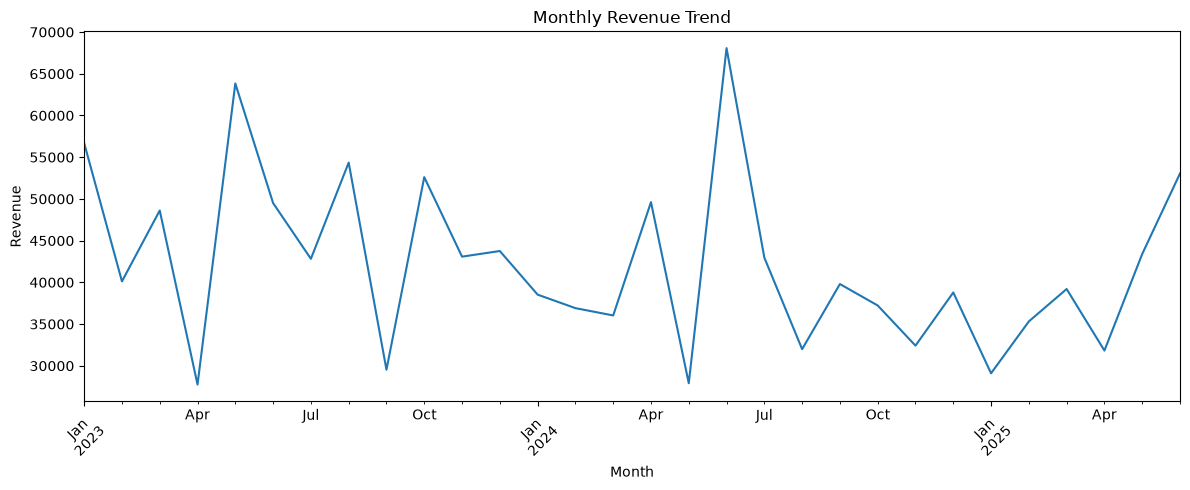

In [411]:
monthly_sales.plot(
    kind="line",
    figsize=(12, 5),
    title="Monthly Revenue Trend"
)

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [412]:
!pip install matplotlib

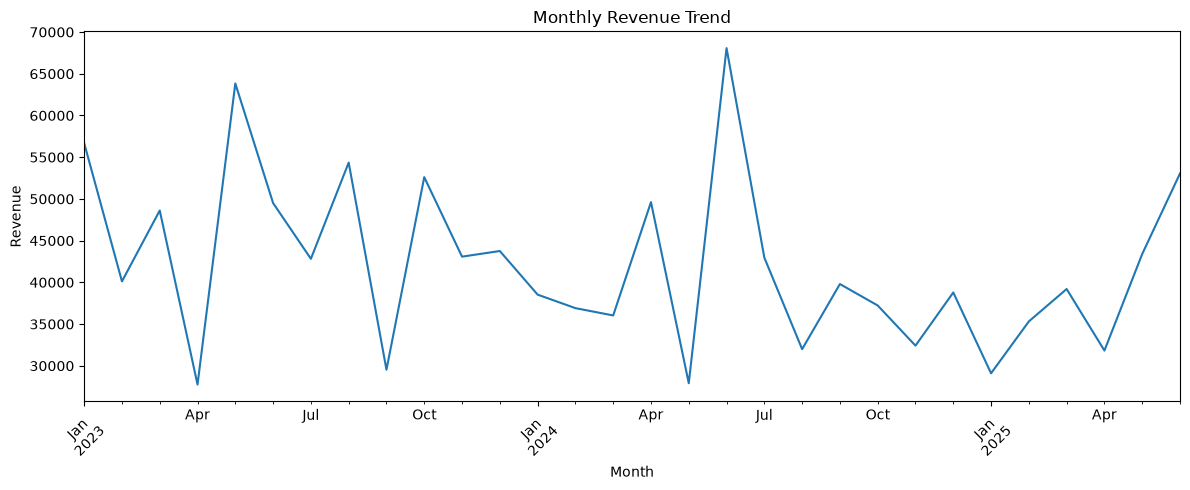

In [413]:
monthly_sales.plot(
    kind="line",
    figsize=(12, 5),
    title="Monthly Revenue Trend"
)

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [414]:
import matplotlib.pyplot as plt

In [415]:
yearly_sales = df.groupby(df["Date"].dt.year)["TotalPrice"].sum()

print(yearly_sales)

Date
2023    552643.24
2024    480235.87
2025    231882.85
Name: TotalPrice, dtype: float64


## 📊 Exploratory Data Analysis (EDA)

After cleaning and validating the dataset, exploratory data analysis was performed to identify patterns and trends in the e-commerce order data.

The analysis focuses on:

* Overall order volume and recorded order value
* Product-wise order performance
* Order status distribution
* Payment method usage
* Coupon code usage
* Referral source performance
* Monthly and yearly order-value trends
* Customer-level order activity
* Quantity-wise order value
* Average Order Value (AOV)
* Relationships between business categories and recorded order value


In [416]:
customer_analysis = df.groupby("CustomerID").agg(
    Orders=("OrderID", "count"),
    Revenue=("TotalPrice", "sum")
).sort_values("Revenue", ascending=False)

print(customer_analysis.head(10))

            Orders  Revenue
CustomerID                 
C38840           2  5723.23
C57276           1  3456.40
C67260           1  3390.80
C13877           1  3384.90
C18404           1  3370.20
C16775           1  3353.75
C65986           1  3352.40
C47778           1  3334.00
C59183           1  3322.55
C25276           1  3313.90


In [417]:
quantity_analysis = df.groupby("Quantity")["TotalPrice"].agg(
    Orders="count",
    Revenue="sum"
)

print(quantity_analysis)

          Orders    Revenue
Quantity                   
1            255   89728.29
2            240  165729.68
3            237  261276.18
4            251  368090.96
5            217  379936.85


In [418]:
payment_revenue = df.groupby("PaymentMethod")["TotalPrice"].agg(
    Orders="count",
    Revenue="sum"
).sort_values("Revenue", ascending=False)

print(payment_revenue)

               Orders    Revenue
PaymentMethod                   
Credit Card       234  263847.63
Online            258  262442.94
Cash              246  259786.29
Gift Card         230  246323.92
Debit Card        232  232361.18


In [419]:
status_revenue = df.groupby("OrderStatus")["TotalPrice"].agg(
    Orders="count",
    Revenue="sum"
).sort_values("Revenue", ascending=False)

print(status_revenue)

             Orders    Revenue
OrderStatus                   
Cancelled       250  276396.21
Pending         237  256328.15
Shipped         235  246159.58
Returned        247  243277.70
Delivered       231  242600.32


In [420]:
coupon_revenue = df.groupby("CouponCode")["TotalPrice"].agg(
    Orders="count",
    Revenue="sum"
).sort_values("Revenue", ascending=False)

print(coupon_revenue)

            Orders    Revenue
CouponCode                   
FREESHIP       313  335036.99
No Coupon      309  322401.41
SAVE10         286  304840.02
WINTER15       292  302483.54


In [421]:
referral_revenue = df.groupby("ReferralSource")["TotalPrice"].agg(
    Orders="count",
    Revenue="sum"
).sort_values("Revenue", ascending=False)

print(referral_revenue)

                Orders    Revenue
ReferralSource                   
Instagram          259  275285.45
Email              250  261808.55
Google             241  250441.48
Facebook           228  250410.90
Referral           222  226815.58


In [422]:
product_aov = df.groupby("Product")["TotalPrice"].mean().sort_values(
    ascending=False
)

print(product_aov)

Product
Laptop     1110.558150
Chair      1098.989382
Printer    1080.732652
Monitor    1077.616012
Tablet     1042.284637
Desk        985.058412
Phone       972.579423
Name: TotalPrice, dtype: float64


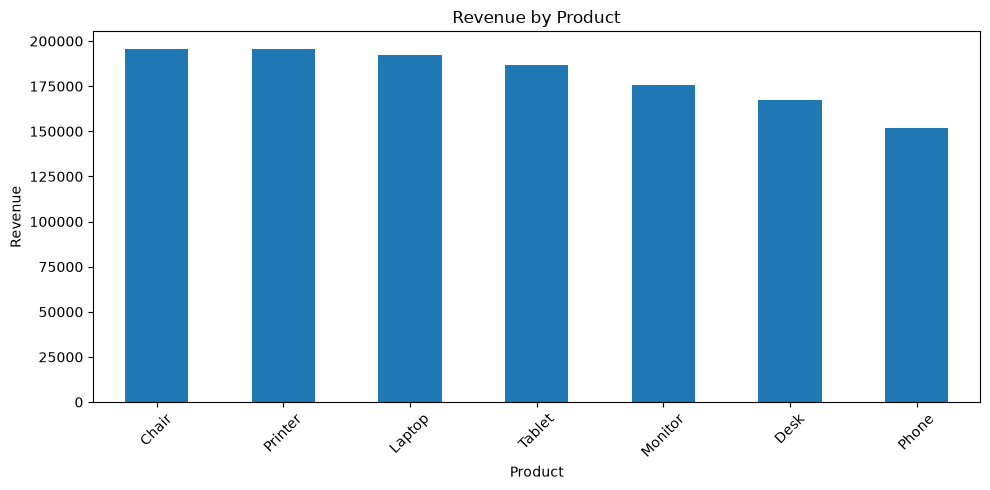

In [423]:
product_revenue = df.groupby("Product")["TotalPrice"].sum().sort_values(ascending=False)

product_revenue.plot(
    kind="bar",
    figsize=(10, 5),
    title="Revenue by Product"
)

plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

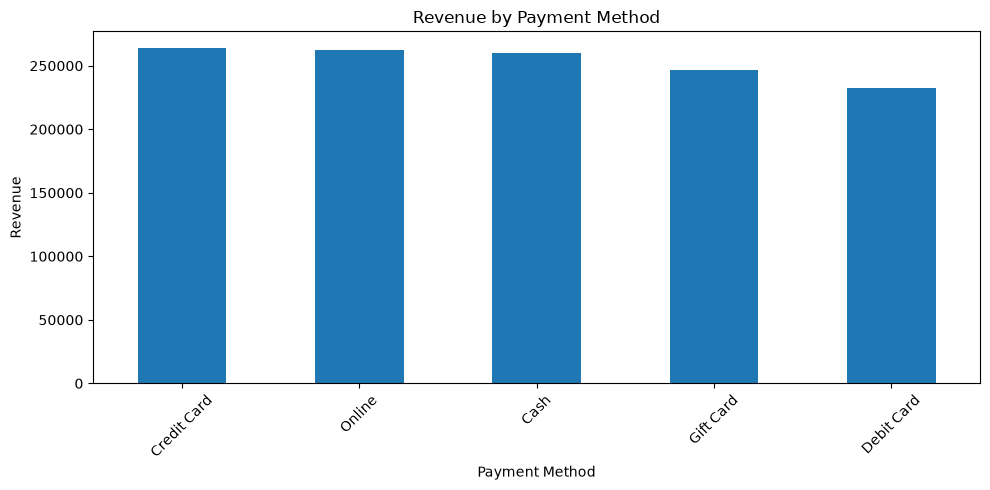

In [424]:
payment_revenue["Revenue"].plot(
    kind="bar",
    figsize=(10, 5),
    title="Revenue by Payment Method"
)

plt.xlabel("Payment Method")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

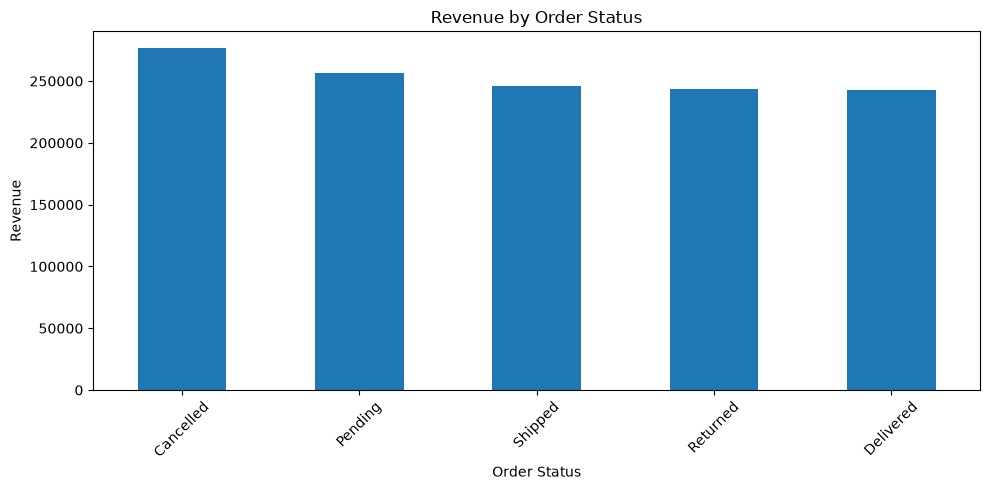

In [425]:
status_revenue["Revenue"].plot(
    kind="bar",
    figsize=(10, 5),
    title="Revenue by Order Status"
)

plt.xlabel("Order Status")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

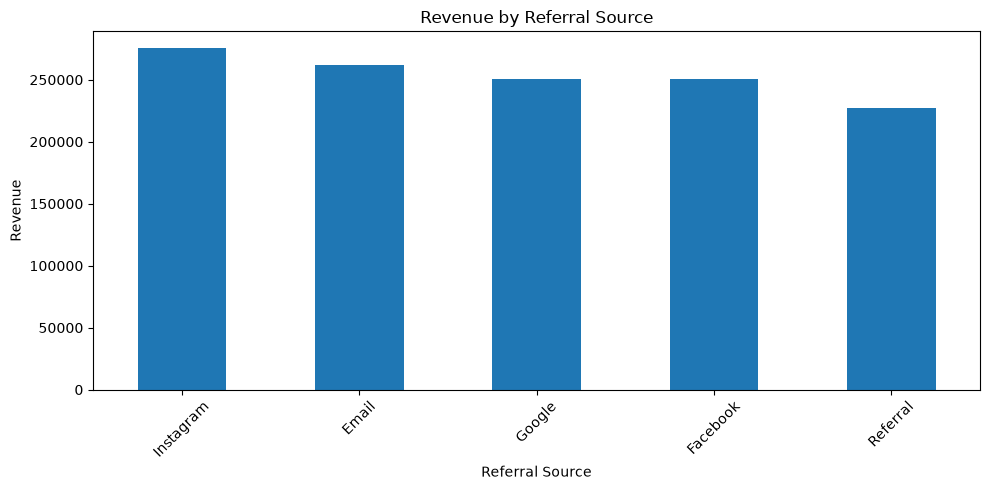

In [426]:
referral_revenue["Revenue"].plot(
    kind="bar",
    figsize=(10, 5),
    title="Revenue by Referral Source"
)

plt.xlabel("Referral Source")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

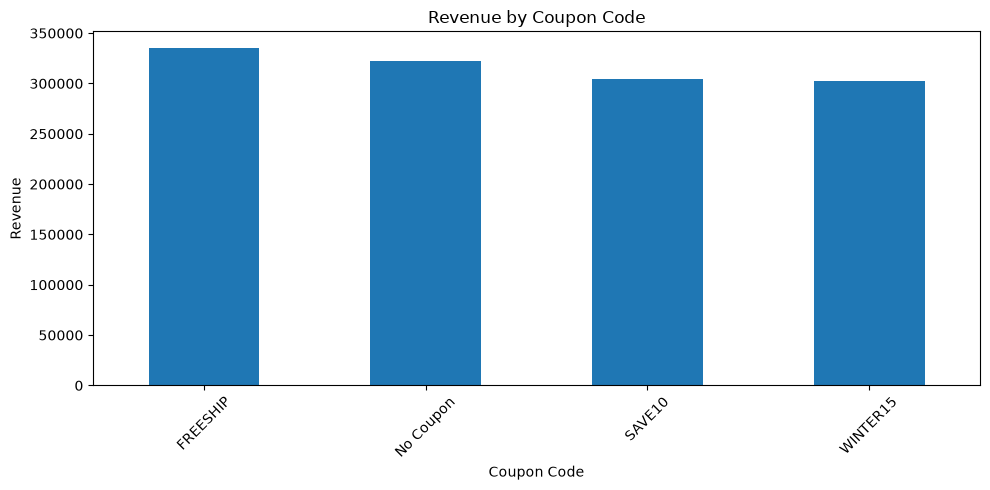

In [427]:
coupon_revenue["Revenue"].plot(
    kind="bar",
    figsize=(10, 5),
    title="Revenue by Coupon Code"
)

plt.xlabel("Coupon Code")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [428]:
print("===== FINAL PROJECT SUMMARY =====")

print("Total Orders:", len(df))
print("Total Revenue:", round(df["TotalPrice"].sum(), 2))
print("Average Order Value:", round(df["TotalPrice"].mean(), 2))

print("\nTop Product by Revenue:")
print(product_analysis["Revenue"].idxmax(), "-", round(product_analysis["Revenue"].max(), 2))

print("\nTop Product by Average Order Value:")
print(product_aov.idxmax(), "-", round(product_aov.max(), 2))

print("\nTop Payment Method by Revenue:")
print(payment_revenue["Revenue"].idxmax(), "-", round(payment_revenue["Revenue"].max(), 2))

print("\nTop Referral Source by Revenue:")
print(referral_revenue["Revenue"].idxmax(), "-", round(referral_revenue["Revenue"].max(), 2))

print("\nTop Coupon by Revenue:")
print(coupon_revenue["Revenue"].idxmax(), "-", round(coupon_revenue["Revenue"].max(), 2))

print("\nHighest Revenue Month:")
print(monthly_sales.idxmax(), "-", round(monthly_sales.max(), 2))

===== FINAL PROJECT SUMMARY =====
Total Orders: 1200
Total Revenue: 1264761.96
Average Order Value: 1053.97

Top Product by Revenue:
Chair - 195620.11

Top Product by Average Order Value:
Laptop - 1110.56

Top Payment Method by Revenue:
Credit Card - 263847.63

Top Referral Source by Revenue:
Instagram - 275285.45

Top Coupon by Revenue:
FREESHIP - 335036.99

Highest Revenue Month:
2024-06 - 68068.54


## 📝 Conclusion

This project analyzed an e-commerce orders dataset containing 1,200 records using Python, Pandas, and Matplotlib.

The analysis identified patterns across products, payment methods, order statuses, coupon codes, referral sources, customers, quantities, and time periods. The data was also thoroughly cleaned and validated before analysis to improve the reliability of the results.

The analysis shows that different product and business categories have varying levels of order activity and recorded order value. Monthly order value also fluctuates across the available period, providing useful information for understanding sales patterns.

Overall, the project demonstrates a complete data analysis workflow, from data inspection and cleaning to exploratory analysis, visualization, and interpretation.

## ⚠️ Limitations

* The dataset covers January 2023 to June 2025, so **2025 represents only a partial year**.
* `TotalPrice` represents recorded order value and should not automatically be interpreted as realized revenue because the dataset includes cancelled, returned, and pending orders.
* Observed relationships between categories and order value represent **associations, not causal effects**.
* The dataset does not provide enough information to determine the reasons behind changes in order value or customer behavior.
